In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Image procesing

In [ ]:
import cv2
import pandas
import seaborn
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [ ]:
path1 = '/content/drive/MyDrive/0_dataset/raw/ctt_sis/00045.png'

In [ ]:
def plot_ (img1) :
    plt.figure(figsize = (20,5))

    plt.subplot(1,2,1)
    plt.imshow(img1, 'gray')

    plt.axis('off')

In [ ]:
img1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)

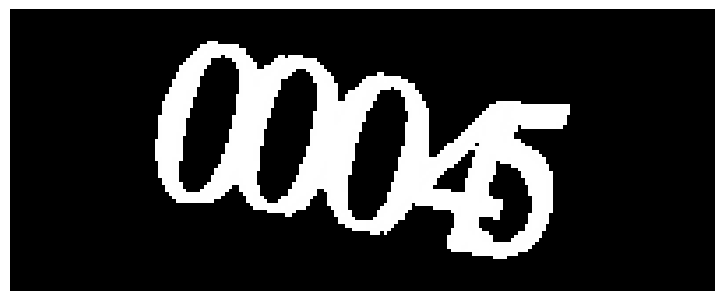

In [ ]:
plot_(img1)

### Adaptive Thresholding
Algorithms determine the threshold for a pixel based on its surrounding regions. So we get different thresholds for different regions of the same image which gives better result for images with varying illumination.

In [ ]:
thresh_img1 = cv2.adaptiveThreshold(img1, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 145, 0)
thresh_img1 = ~thresh_img1

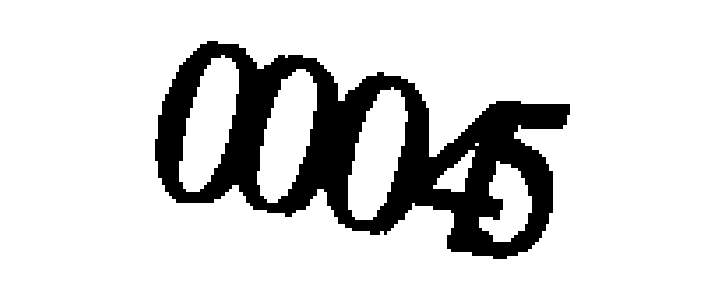

In [ ]:
plot_(thresh_img1)

### Closing
Dilation followed by Erosion.

In [ ]:
close_img1 = cv2.morphologyEx(thresh_img1, cv2.MORPH_CLOSE, np.ones((5,2), np.uint8))

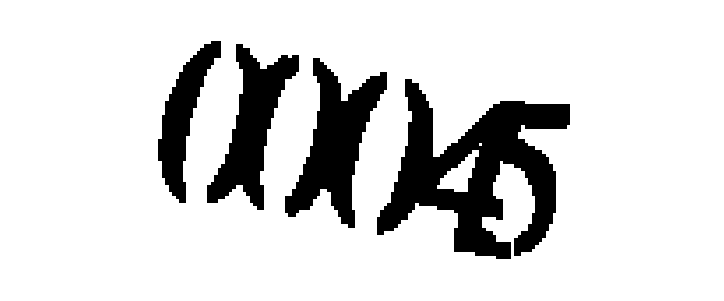

In [ ]:
plot_(close_img1)

### Dilation
Involves a kernel being scanned over the entire image. The maximal pixel value is calculated in the kernel region and the anchor point of the kernel is updated to that value. This causes the white region to expand in the image.

In [ ]:
dilate_img1 = cv2.dilate(close_img1, np.ones((2,2), np.uint8), iterations = 1)

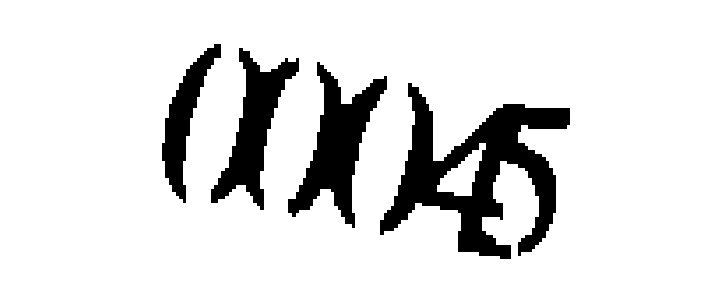

In [ ]:
plot_(dilate_img1)

### Smoothing Images (Blurring)
Involves convolving a low-pass filter with an image, to remove high frequency components ie. noises and edges from the image.

In [ ]:
gauss_img1 = cv2.GaussianBlur(dilate_img1, (1,1), 0)

gauss_img1 = cv2.resize(gauss_img1,(200,50),interpolation=cv2.INTER_LINEAR)

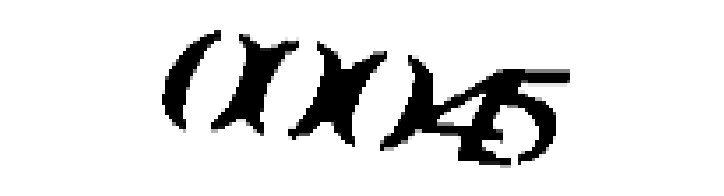

In [ ]:
plot_(gauss_img1)

### PartitioningBatchNormalization

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
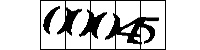

In [ ]:
cv2.rectangle(gauss_img1, (40,0), (65,49), 0, 1)
cv2.rectangle(gauss_img1, (65,0), (90,49), 0, 1)
cv2.rectangle(gauss_img1, (90,0), (115,49), 0, 1)
cv2.rectangle(gauss_img1, (115,0), (140,49),0, 1)
cv2.rectangle(gauss_img1, (140,0),(165,49),0, 1)

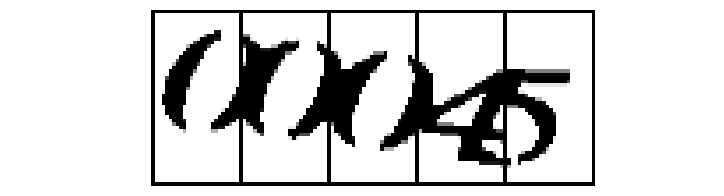

In [ ]:
plot_(gauss_img1)


# Converting images to appropriate samples

In [ ]:
path = '/content/drive/MyDrive/0_dataset/raw/ctt_sis'

In [ ]:
def t_img (img) :
    img_di = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 145, 0)
    return ~img_di

def c_img (img) :
    return cv2.morphologyEx(img, cv2.MORPH_CLOSE, np.ones((5,2), np.uint8))

def d_img (img) :
    return cv2.dilate(img, np.ones((2,2), np.uint8), iterations = 1)

def b_img (img) :
    img = cv2.GaussianBlur(img, (1,1), 0)
    return cv2.resize(img,(200,50),interpolation=cv2.INTER_LINEAR)

In [ ]:
import os
from PIL import Image
from keras.preprocessing.image import img_to_array

In [ ]:
X = []
y = []

for image in os.listdir(path) :

    if not image.endswith('.png'):
        continue

    name_without_ext = image.split('.png')[0]
    label = name_without_ext.split('_')[0]

    img = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)

    img = t_img(img)
    img = c_img(img)
    img = d_img(img)
    img = b_img(img)

    image_list = [
        img[0:50, 40:65],
        img[0:50, 65:90],
        img[0:50, 90:115],
        img[0:50, 115:140],
        img[0:50, 140:165]
    ]

    for i in range(5) :
        X.append(img_to_array(Image.fromarray(image_list[i])))
        y.append(image[i].lower())
X = np.array(X)
y = np.array(y)

In [ ]:
print(X.shape)
print(y.shape)

(4995, 50, 25, 1)
(4995,)


# Initial Analysis and Data Wrangling

### Scale b/w 0 and 1

In [ ]:
X /= 255.0

[]

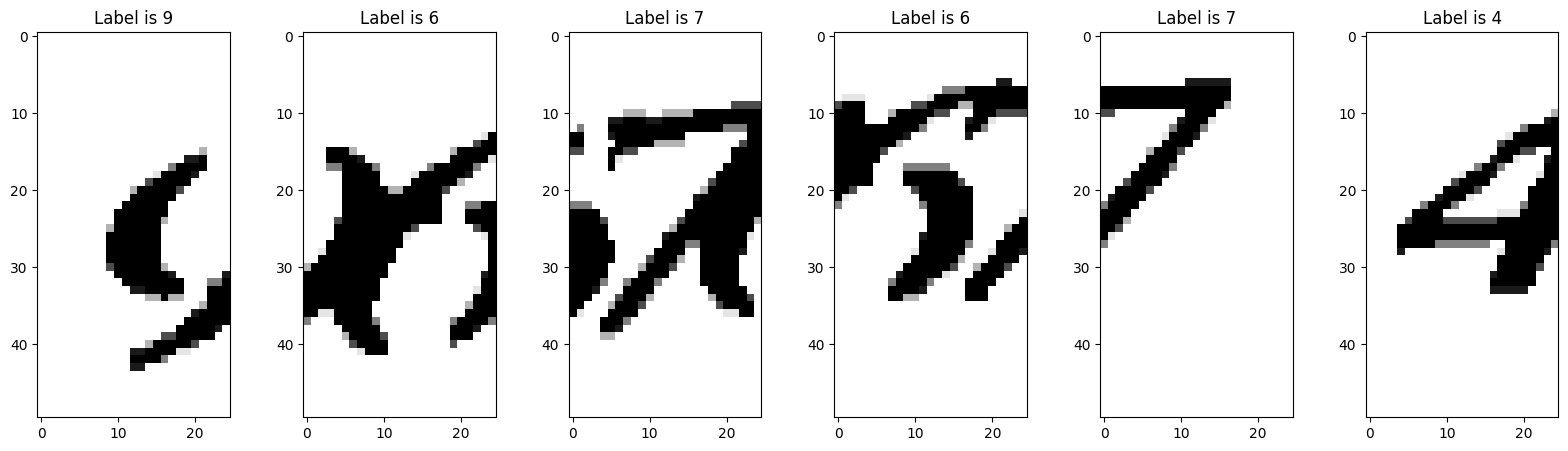

In [ ]:
plt.figure(figsize = (20,5))
for i in range(6) :
    plt.subplot(1,6,i+1)
    plt.imshow(X[i], 'gray')
    plt.title('Label is ' + str(y[i]))
plt.plot()

In [ ]:
temp = set(y)
for t in temp :
    print('Occurance count of ' + t + ' : ' + str(len(y[y == t])))

Occurance count of 3 : 555
Occurance count of 0 : 549
Occurance count of 4 : 555
Occurance count of 5 : 576
Occurance count of 9 : 571
Occurance count of 6 : 513
Occurance count of 8 : 522
Occurance count of 2 : 558
Occurance count of 7 : 596


In [ ]:
 temp_df = pandas.DataFrame({'labels' : [t for t in temp], 'Count' : [len(y[y==t]) for t in temp]})

/tmp/ipykernel_1231/2509206017.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.barplot(x = 'labels', y = 'Count', data = temp_df, palette = 'Blues_d')


Text(0.5, 1.0, 'Label distribution in CAPTCHAS')

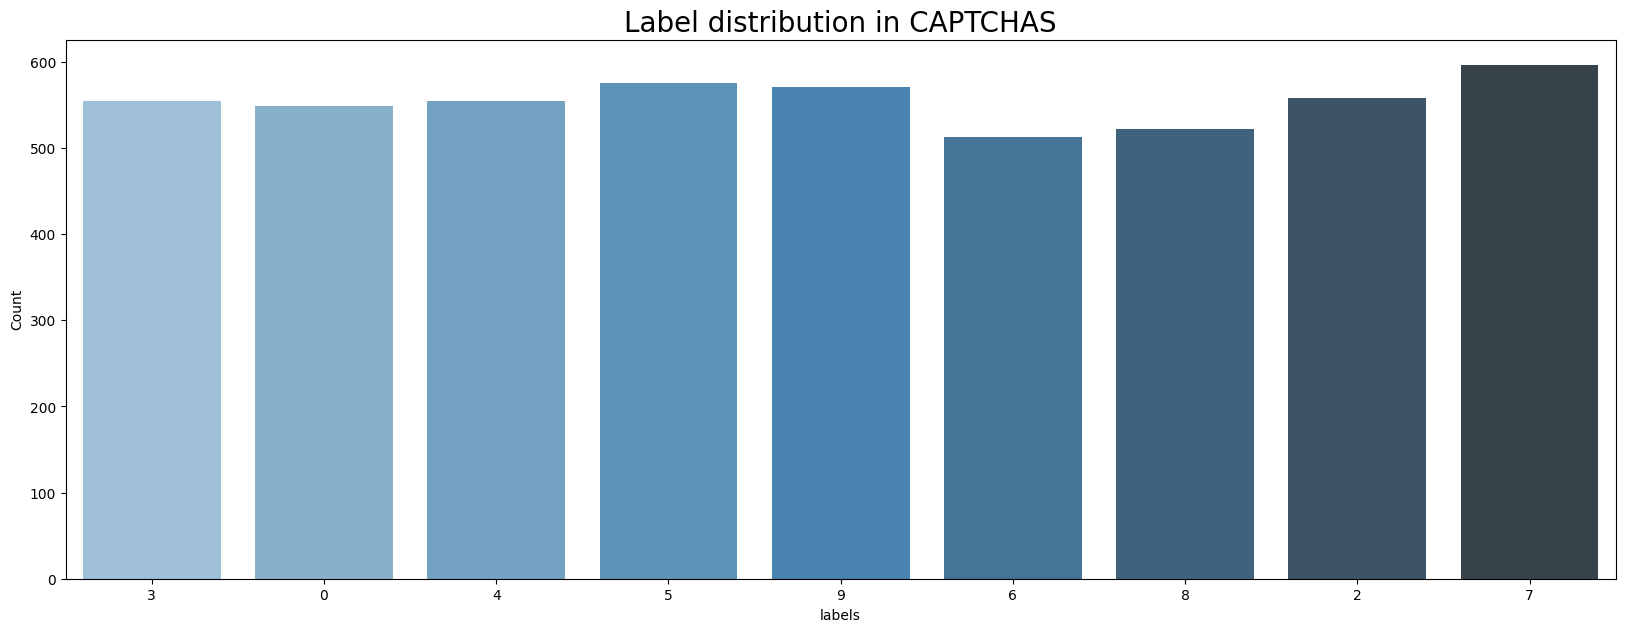

In [ ]:
plt.figure(figsize = (20,7))
seaborn.barplot(x = 'labels', y = 'Count', data = temp_df, palette = 'Blues_d')
plt.title('Label distribution in CAPTCHAS', fontsize = 20)

### One hot encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

y_combine = LabelEncoder().fit_transform(y)
y_one_hot = OneHotEncoder(sparse_output=False).fit_transform(y_combine.reshape(len(y_combine), 1))

In [ ]:
print('letter most : ' + str(y[1]))
print('label : ' + str(y_combine[1]))
print('Count : ' + str(len(y_combine[y_combine == y_combine[1]])))

letter most : 6
label : 5
Count : 513


In [ ]:
info = {y_combine[i] : y[i] for i in range(len(y))}


In [ ]:
print(X.shape)
print(y_one_hot.shape)  # one hot encoded form

(4995, 50, 25, 1)
(4995, 9)


# Train test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size = 0.2, random_state = 1)

In [ ]:
y_temp = np.argmax(y_test, axis = 1)

In [ ]:
temp = set(y_temp)
temp_df = pandas.DataFrame({'labels' : [info[t] for t in temp], 'Count' : [len(y_temp[y_temp == t]) for t in temp]})

/tmp/ipykernel_1231/3258029991.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.barplot(x = 'labels', y = 'Count', data = temp_df, palette = 'Blues_d')


Text(0.5, 1.0, 'Label distribution in test set')

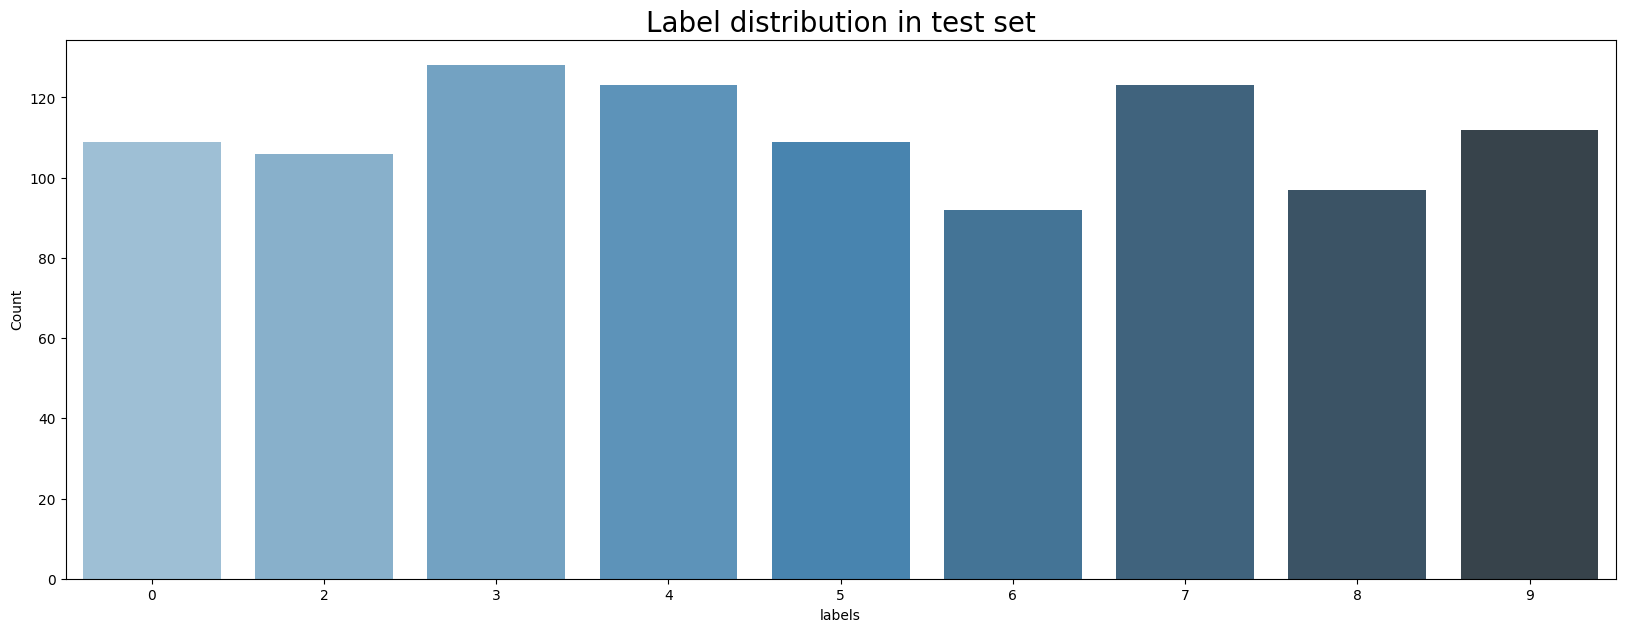

In [ ]:
plt.figure(figsize = (20,7))
seaborn.barplot(x = 'labels', y = 'Count', data = temp_df, palette = 'Blues_d')
plt.title('Label distribution in test set', fontsize = 20)

# Model Creation

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Conv2D
from keras.layers import Flatten
from keras.layers import MaxPooling2D
from keras.layers import BatchNormalization

from keras.layers import Dropout
from keras.layers import Input

In [ ]:
print(X_train.shape)
print(y_train.shape)

(3996, 50, 25, 1)
(3996, 9)


In [ ]:
print(X_test.shape)
print(y_test.shape)

(999, 50, 25, 1)
(999, 9)


In [ ]:
def conv_layer (filterx) :

    model = Sequential()

    model.add(Conv2D(filterx, (3,3), padding = 'same', activation = 'relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(MaxPooling2D(pool_size = (2,2), padding = 'same'))

    return model

In [ ]:
def dens_layer (hiddenx) :

    model = Sequential()

    model.add(Dense(hiddenx, activation = 'relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    return model

In [ ]:
def cnn (filter1, filter2, filter3, hidden1, hidden2) :

    model = Sequential()
    model.add(Input((50, 25, 1,)))

    model.add(conv_layer(filter1))
    model.add(conv_layer(filter2))
    model.add(conv_layer(filter3))

    model.add(Flatten())
    model.add(dens_layer(hidden1))
    model.add(dens_layer(hidden2))

    model.add(Dense(9, activation = 'softmax'))

    model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

    return model

# Data augmentation and Oversampling

### SMOTE

In [ ]:
X_train = np.reshape(X_train, (3996,50*25*1))


In [ ]:
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# ==============================================================
# BƯỚC 1: Tiền xử lý đưa X và y về dạng phù hợp cho SMOTE
# ==============================================================
# 1. Biến y_train từ One-Hot (2D) về dạng index 1 chiều (1D)
y_train_1d = np.argmax(y_train, axis=1)

# Lọc bỏ các nhãn xuất hiện quá ít (< 6) để SMOTE không bị lỗi
counts = pd.Series(y_train_1d).value_counts()
valid_labels = counts[counts >= 6].index
mask = np.isin(y_train_1d, valid_labels)

X_train_filtered = X_train[mask]
y_train_filtered = y_train_1d[mask]

# 2. "Duỗi" X_train_filtered từ (N, 50, 25, 1) thành 2D (N, 50 * 25 * 1)
num_samples = X_train_filtered.shape[0]
X_train_2d = X_train_filtered.reshape((num_samples, -1))

# ==============================================================
# BƯỚC 2: Chạy SMOTE
# ==============================================================
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=1)
X_train_smote_2d, y_train_smote_1d = smote.fit_resample(X_train_2d, y_train_filtered)

# ==============================================================
# BƯỚC 3: Phục hồi lại dữ liệu về định dạng ban đầu cho Model
# ==============================================================
# 1. "Cuộn" X lại thành dạng ảnh 4D (N, 50, 25, 1)
X_train = X_train_smote_2d.reshape((-1, *X_train.shape[1:]))

y_train = to_categorical(y_train_smote_1d, num_classes=y_train.shape[1])

print("Hoàn thành SMOTE!")
print("Kích thước X_train", X_train.shape)

# Bây giờ bạn dùng X_train_smote và y_train_smote để đưa vào model fit nhé!


Hoàn thành SMOTE!
Kích thước X_train (4257, 1250)


In [ ]:
print(X_train.shape)
print(y_train.shape)

(4257, 1250)
(4257, 9)


In [ ]:
X_train = np.reshape(X_train, (4257,50,25,1))

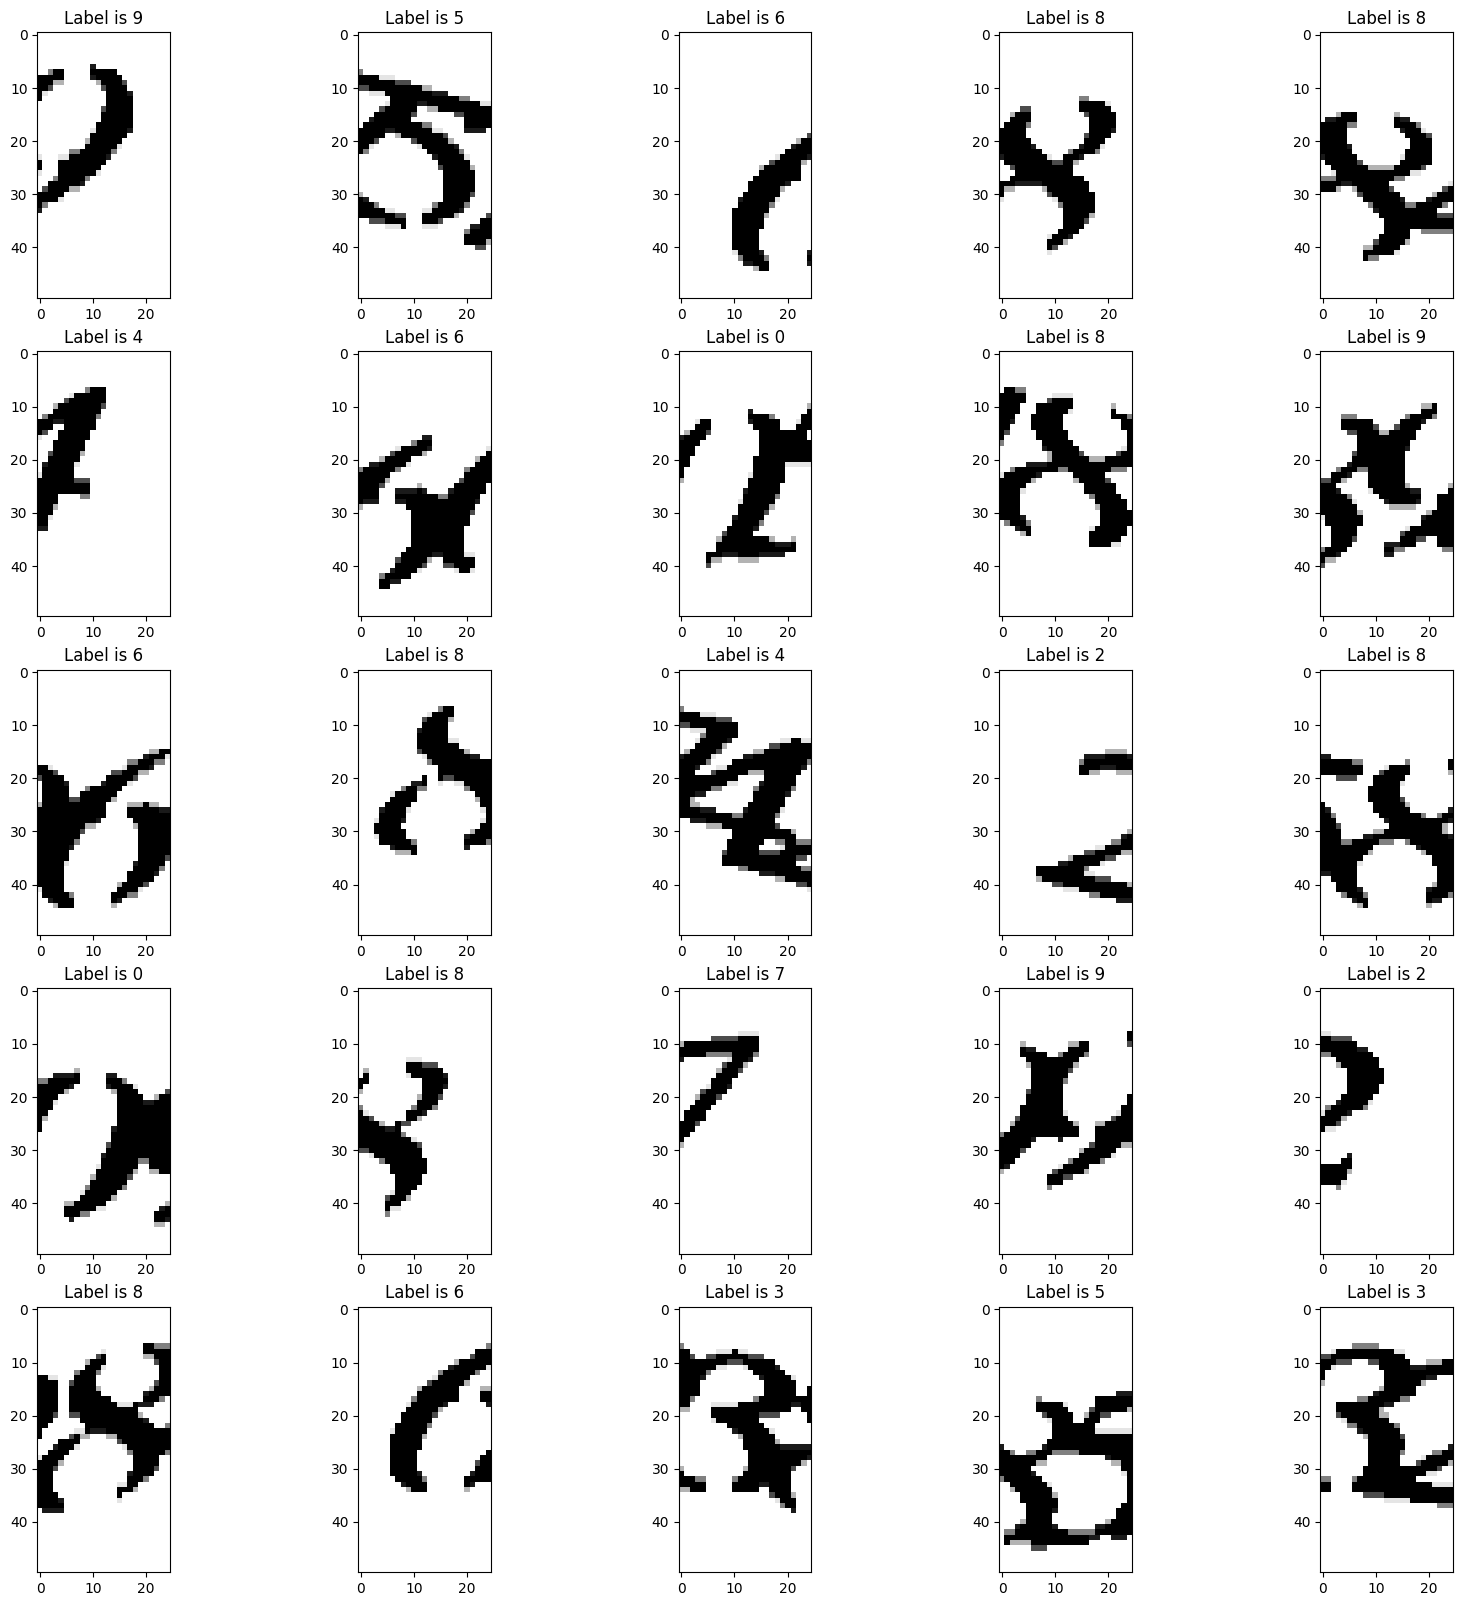

In [ ]:
plt.figure(figsize = (20,20))

lo = 0
# Tự động lấy kích thước lớn nhất của tập X_train
hi = len(X_train)

for i in range(25):
    plt.subplot(5,5,i+1)
    # Random từ 0 đến len(X_train) - 1
    x = np.random.randint(lo, hi)

    plt.imshow(X_train[x], 'gray')
    plt.title('Label is ' + str(info[np.argmax(y_train[x])]))
plt.show()


### ImageDataGenerator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Code của bạn:
traingen = ImageDataGenerator(rotation_range = 5, width_shift_range = [-2,2])
traingen.fit(X_train)


In [ ]:
train_set = traingen.flow(X_train, y_train)


In [ ]:
trainX, trainy = next(train_set)


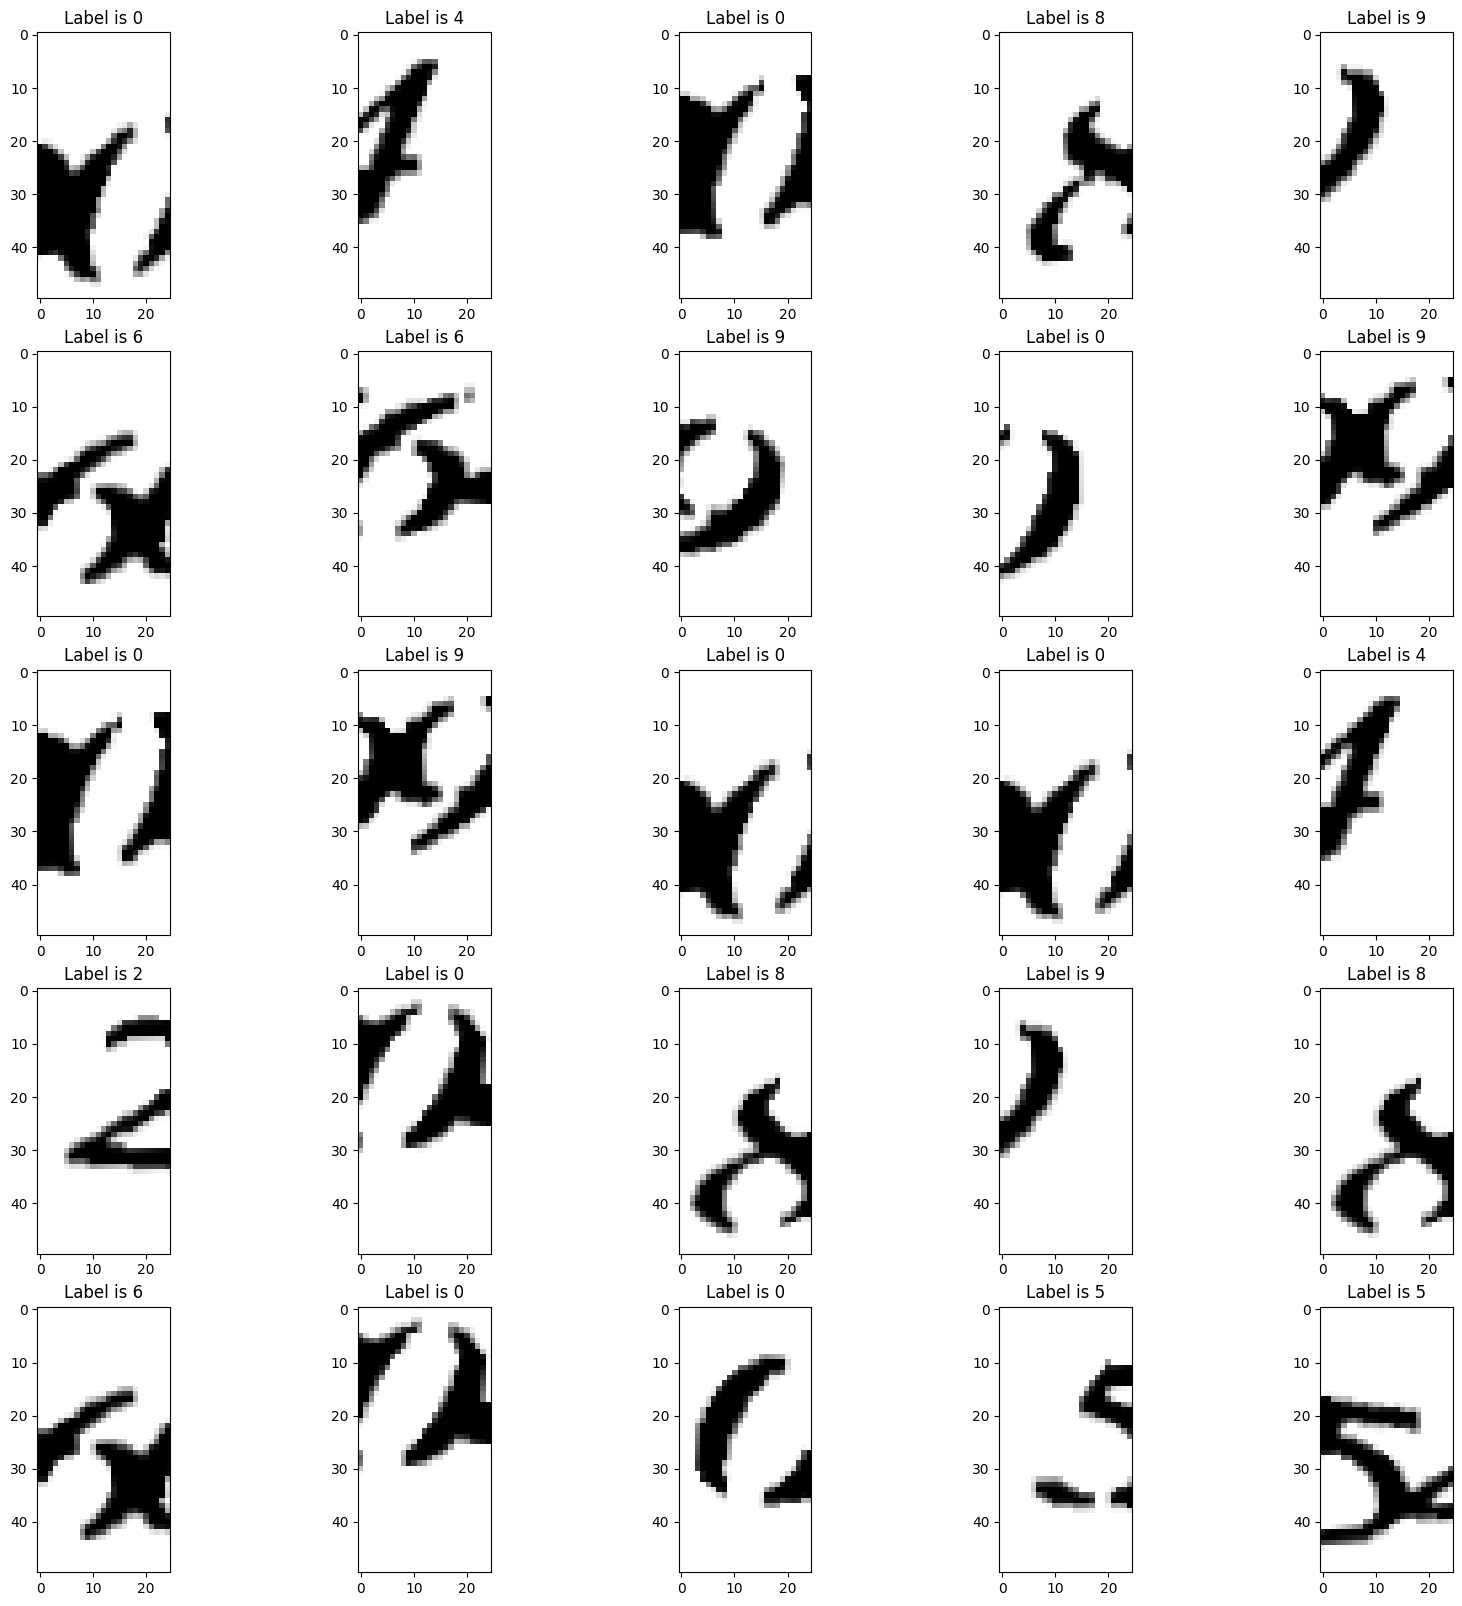

In [ ]:
plt.figure(figsize = (20,20))

hi = 32
lo = 0

for i in range(25) :
    plt.subplot(5,5,i+1)
    x = np.random.randint(lo, hi)
    plt.imshow(trainX[x], 'gray')
    plt.title('Label is ' + str(info[np.argmax(trainy[x])]))
plt.show()

# Model Training

In [ ]:
model = cnn(128, 32, 16, 32, 32)
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 25, 13, 128)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 13, 7, 32)      │        37,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 7, 4, 16)       │         4,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 32)             │        14,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_11 (Sequential)      │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,481 (232.35 KB)

 Trainable params: 59,001 (230.47 KB)

 Non-trainable params: 480 (1.88 KB)

### ModelCheckpoint and ReduceLROnPlateau


In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
checkp = ModelCheckpoint('./result_model.keras', monitor = 'val_loss', verbose = 1, save_best_only = True)

In [ ]:
reduce = ReduceLROnPlateau(monitor = 'val_loss', patience = 5, verbose = 1)


In [ ]:
print(X_train.shape)
print(y_train.shape)

(4257, 50, 25, 1)
(4257, 9)


In [ ]:
history = model.fit(
    traingen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[checkp]
)


Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1712 - loss: 2.6416
Epoch 1: val_loss improved from None to 2.16666, saving model to ./result_model.keras

Epoch 1: finished saving model to ./result_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - accuracy: 0.2222 - loss: 2.3281 - val_accuracy: 0.1712 - val_loss: 2.1667
Epoch 2/20
132/134 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4335 - loss: 1.6196
Epoch 2: val_loss improved from 2.16666 to 1.99814, saving model to ./result_model.keras

Epoch 2: finished saving model to ./result_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4994 - loss: 1.4490 - val_accuracy: 0.2272 - val_loss: 1.9981
Epoch 3/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6405 - loss: 1.0505
Epoch 3: val_loss improved from 1.99814 to 1.50838, saving model to ./result_model.keras

Epoch 3: finished saving model to ./result_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6667 - loss: 0

Text(0.5, 1.0, 'Model accuracy wrt Epoch')

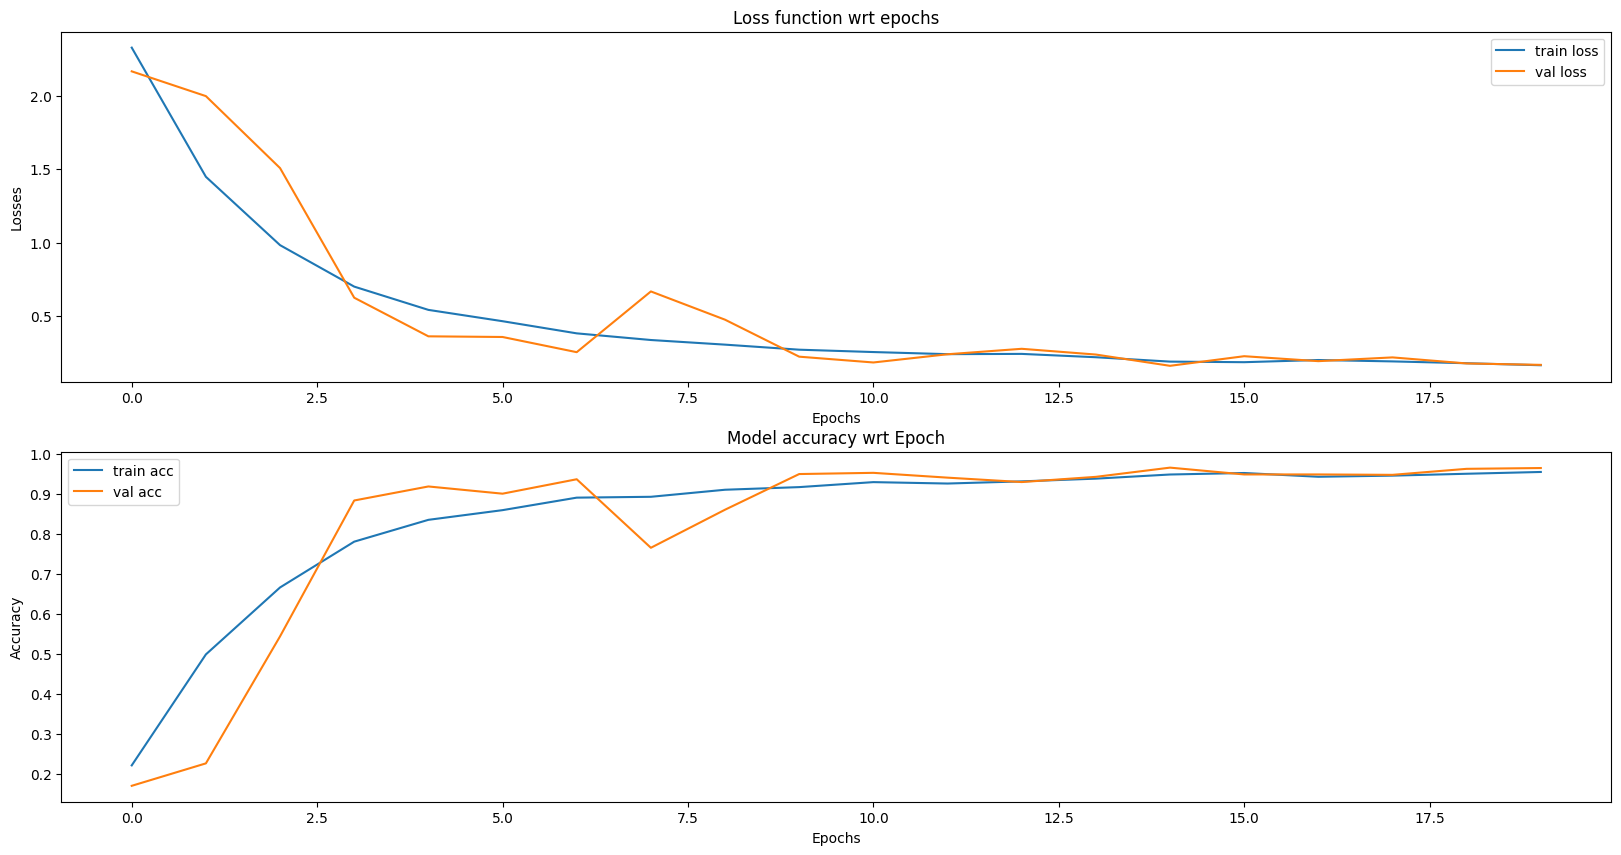

In [ ]:
plt.figure(figsize = (20,10))
plt.subplot(2,1,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.legend(['train loss','val loss'])
plt.title('Loss function wrt epochs')

plt.subplot(2,1,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train acc' , 'val acc'])
plt.title('Model accuracy wrt Epoch')

# Prediction

In [ ]:
from keras.models import load_model


In [ ]:
model = load_model('./result_model.keras')


In [ ]:
pred = model.predict(X_test)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


In [ ]:
pred = np.argmax(pred, axis = 1)
yres = np.argmax(y_test,axis= 1)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
target_name = []
for i in sorted(info) :
    target_name.append(info[i])

In [ ]:
target_name


[np.str_('0'),
 np.str_('2'),
 np.str_('3'),
 np.str_('4'),
 np.str_('5'),
 np.str_('6'),
 np.str_('7'),
 np.str_('8'),
 np.str_('9')]

In [ ]:
print('Accuracy : ' + str(accuracy_score(yres, pred)))
print(classification_report(yres, pred, target_names=target_name, labels=np.arange(len(target_name))))

Accuracy : 0.965965965965966
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       109
           2       0.99      0.95      0.97       106
           3       0.96      0.95      0.96       128
           4       0.96      0.98      0.97       123
           5       0.98      0.95      0.97       109
           6       0.89      0.99      0.94        92
           7       0.98      0.94      0.96       123
           8       0.98      0.98      0.98        97
           9       0.96      0.99      0.97       112

    accuracy                           0.97       999
   macro avg       0.97      0.97      0.97       999
weighted avg       0.97      0.97      0.97       999



# Testing on samples

In [ ]:
import os

def get_demo(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.imshow(img, 'gray')
    plt.axis('off')
    plt.show()

    img = t_img(img)
    img = c_img(img)
    img = d_img(img)
    img = b_img(img)

    image_list = [
        img[0:505, 40:65],
        img[0:50, 65:90],
        img[0:50, 90:115],
        img[0:50, 115:140],
        img[0:50, 140:165]
    ]

    plt.imshow(img, 'gray')
    plt.axis('off')
    plt.show()

    Xdemo = []
    for i in range(5):
        Xdemo.append(img_to_array(Image.fromarray(image_list[i])))

    Xdemo = np.array(Xdemo)
    Xdemo /= 255.0

    # Dự đoán bằng mô hình
    ydemo = model.predict(Xdemo)
    ydemo = np.argmax(ydemo, axis=1)

    predicted_captcha = ""
    for res in ydemo:
        predicted_captcha += str(info[res])

    print("Dự đoán của AI   :", predicted_captcha)
    print("Tên file gốc (GT):", os.path.basename(img_path))


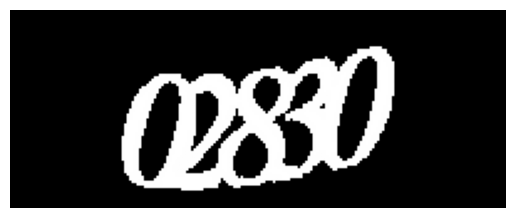

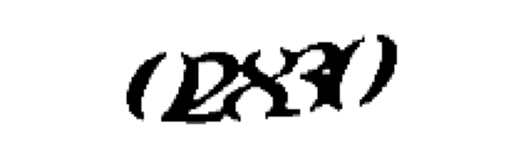

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
Dự đoán của AI   : 02830
Tên file gốc (GT): 02830.png


In [ ]:
get_demo('/content/drive/MyDrive/0_dataset/raw/ctt_sis/02830.png')